# Electricity Load Forecasting: Linear Regression Baseline

In this notebook, we load our preprocessed time-series data and train a Linear Regression model. This will serve as our baseline to establish how well standard autoregressive features (lags and rolling means) predict future electricity consumption.

## 1. Imports, Data Loading and Client Selection
We import pandas for data handling, and scikit-learn for our model, metrics, and data splitting.

We load the highly compressed Parquet file. To evaluate the model clearly and avoid overwhelming system memory during this baseline test, we will filter the dataset to isolate 30 client.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import random 

print("Loading processed data...")
df_long = pd.read_parquet('processed_electricity_data.parquet')

# Select a specific client for modeling
random.seed(42)
all_clients = df_long['ClientID'].unique().tolist()
sampled_clients = random.sample(all_clients, 30)

print(f"Filtering data for {len(sampled_clients)} sampled clients...")
df_sample = df_long[df_long['ClientID'].isin(sampled_clients)].copy()

Loading processed data...
Filtering data for 30 sampled clients...


## 2. Data Preparation
Machine learning models require numerical inputs. We convert our boolean holiday/weekend flags to integers (0 and 1). Furthermore, cyclical categorical variables like 'Hour' and 'Weekday' must be One-Hot Encoded so the model doesn't assume that Hour 2 is twice as large as Hour 1.

In [10]:
# Convert booleans to integers
# Convert booleans to integers
df_sample['Is_Weekend'] = df_sample['Is_Weekend'].astype(int)
df_sample['Is_Holiday'] = df_sample['Is_Holiday'].astype(int)

# One-Hot Encoding for categorical time and segmentation variables
print("One-Hot Encoding categorical features...")
df_model = pd.get_dummies(df_sample, columns=['Hour', 'Weekday', 'Consumer_Category'], drop_first=True)

# Standardize weather (global, doesn't need to be per-client)
weather_cols = ['Temp_National_Avg', 'HDH', 'CDH']
scaler_weather = StandardScaler()
df_sample[weather_cols] = scaler_weather.fit_transform(df_sample[weather_cols])

# Create standardizers for each client to handle scale differences
print("Standardizing numerical features per client...")
df_sample['Consumption_Scaled'] = df_sample.groupby('ClientID', observed=True)['Consumption'].transform(lambda x: StandardScaler().fit_transform(x.values.reshape(-1, 1)).flatten())
df_sample['Lag_15min_Scaled'] = df_sample.groupby('ClientID', observed=True)['Lag_15min'].transform(lambda x: StandardScaler().fit_transform(x.values.reshape(-1, 1)).flatten())
df_sample['Lag_24h_Scaled'] = df_sample.groupby('ClientID', observed=True)['Lag_24h'].transform(lambda x: StandardScaler().fit_transform(x.values.reshape(-1, 1)).flatten())
df_sample['Rolling_Mean_4h_Scaled'] = df_sample.groupby('ClientID', observed=True)['Rolling_Mean_4h'].transform(lambda x: StandardScaler().fit_transform(x.values.reshape(-1, 1)).flatten())

display(df_sample.head(20))

One-Hot Encoding categorical features...
Standardizing numerical features per client...


,Date,Weekday,Hour,DayMonth,Is_Weekend,Is_Holiday,ClientID,Consumption,Consumer_Category,Temp_National_Avg,HDH,CDH,Lag_15min,Lag_24h,Rolling_Mean_4h,Consumption_Scaled,Lag_15min_Scaled,Lag_24h_Scaled,Rolling_Mean_4h_Scaled
1203208,2012-01-02 00:15:00,1,1,02-01,0,0,MT_013,46.434494,Light,-0.697215,0.664485,-0.527746,43.117744,45.605309,43.791458,-0.650659,-0.730419,-0.670564,-0.779884
1203209,2012-01-02 00:30:00,1,1,02-01,0,0,MT_013,53.067993,Light,-0.697215,0.664485,-0.527746,46.434494,47.263683,44.050583,-0.491143,-0.650661,-0.630685,-0.773080
1203210,2012-01-02 00:45:00,1,1,02-01,0,0,MT_013,49.751244,Light,-0.697215,0.664485,-0.527746,53.067993,53.067993,44.102406,-0.570901,-0.491145,-0.491109,-0.771719
1203211,2012-01-02 01:00:00,1,2,02-01,0,0,MT_013,43.117744,Light,-0.660551,0.608476,-0.527746,49.751244,44.776119,44.102406,-0.730417,-0.570903,-0.690503,-0.771719
1203212,2012-01-02 01:15:00,1,2,02-01,0,0,MT_013,50.580433,Light,-0.660551,0.608476,-0.527746,43.117744,48.092869,44.050583,-0.550961,-0.730419,-0.610746,-0.773080
1203213,2012-01-02 01:30:00,1,2,02-01,0,0,MT_013,49.751244,Light,-0.660551,0.608476,-0.527746,50.580433,53.067993,44.050583,-0.570901,-0.550963,-0.491109,-0.773080
1203214,2012-01-02 01:45:00,1,2,02-01,0,0,MT_013,45.605309,Light,-0.660551,0.608476,-0.527746,49.751244,43.117744,44.465176,-0.670598,-0.570903,-0.730382,-0.762194
1203215,2012-01-02 02:00:00,1,3,02-01,0,0,MT_013,40.630184,Light,-0.698067,0.665786,-0.527746,45.605309,39.800995,44.620647,-0.790235,-0.670600,-0.810139,-0.758111
1203216,2012-01-02 02:15:00,1,3,02-01,0,0,MT_013,41.459370,Light,-0.698067,0.665786,-0.527746,40.630184,40.630184,44.516998,-0.770296,-0.790238,-0.790200,-0.760833
1203217,2012-01-02 02:30:00,1,3,02-01,0,0,MT_013,38.142620,Light,-0.698067,0.665786,-0.527746,41.459370,41.459370,44.309704,-0.850054,-0.770298,-0.770260,-0.766276


## 3. Chronological Train/Test Split


When working with time-series data, we can **never** randomly shuffle and split our data. We must respect the flow of time to prevent "data leakage" (peeking into the future to predict the past). We will use data prior to 2014 for training, and data from 2014 onwards for testing.

In [11]:
cutoff_date = '2014-01-01'

train = df_model[df_model['Date'] < cutoff_date]
test = df_model[df_model['Date'] >= cutoff_date]

# Define features (X) and target (y)
cols_to_drop = ['Date', 'ClientID', 'DayMonth', 'Consumption', 'Consumption_Scaled', 'Lag_15min', 'Lag_24h', 'Rolling_Mean_4h']

X_train = train.drop(columns=cols_to_drop)
y_train = train['Consumption_Scaled']

X_test = test.drop(columns=cols_to_drop)
y_test = test['Consumption_Scaled']

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (2163238, 39)
Testing shape: (1043066, 39)


## 4. Model Training and Evaluation
We train the Linear Regression model on our historical data. We evaluate its performance using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to understand our average prediction error in kilowatts (kW).

In [16]:
print("Training Linear Regression model...")
model = LinearRegression()
model.fit(X_train, y_train)

print("Making predictions on test set...")
y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error (MSE): {rmse:.2f}")

Training Linear Regression model...
Making predictions on test set...
Mean Squared Error (MSE): 0.11


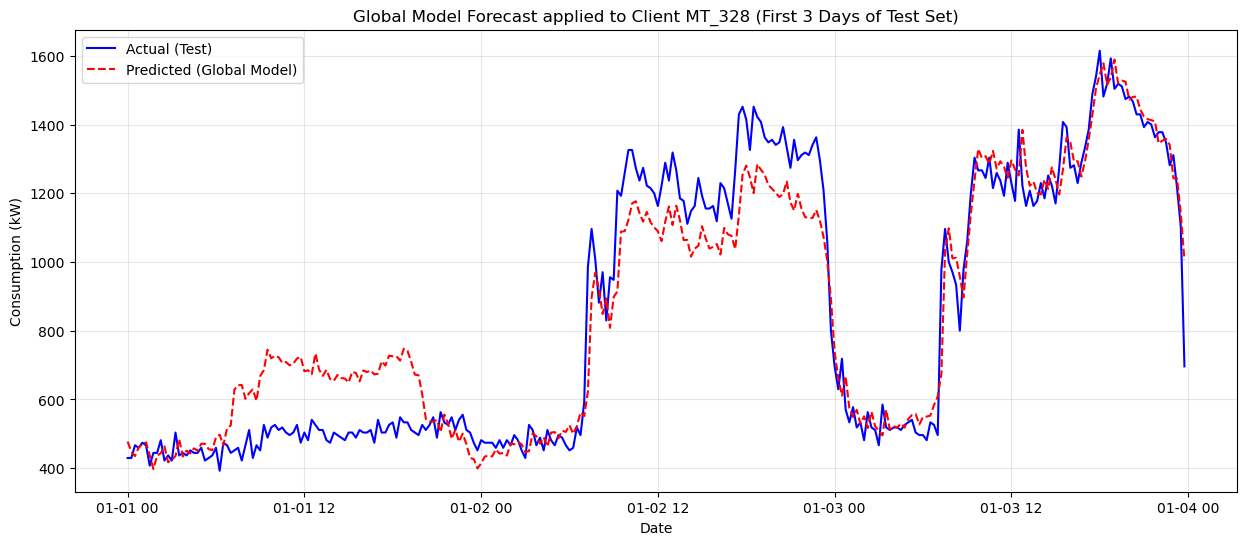

In [17]:
test_client_id = sampled_clients[0]
client_test_data = test[test['ClientID'] == test_client_id].copy()

# Find the indices of this client in the overall test set to extract their specific predictions
client_indices = test['ClientID'] == test_client_id
client_y_pred = y_pred[client_indices]
client_y_actual = client_test_data['Consumption'] # The real, unscaled kW values

# To reverse the scaling, we need to rebuild the scaler for this specific client
client_scaler = StandardScaler()
# We fit the scaler on the client's original training data to get the correct mean and variance
client_train_data = train[train['ClientID'] == test_client_id]['Consumption']
client_scaler.fit(client_train_data.values.reshape(-1, 1))

# Inverse transform the predictions back to kW
client_y_pred_kw = client_scaler.inverse_transform(client_y_pred.reshape(-1, 1)).flatten()

days_to_plot = 288 # Roughly 3 days of 15-min intervals

plt.figure(figsize=(15, 6))
plt.plot(client_test_data['Date'].iloc[:days_to_plot], client_y_actual.iloc[:days_to_plot], label='Actual (Test)', color='blue')
plt.plot(client_test_data['Date'].iloc[:days_to_plot], client_y_pred_kw[:days_to_plot], label='Predicted (Global Model)', color='red', linestyle='--')
plt.title(f'Global Model Forecast applied to Client {test_client_id} (First 3 Days of Test Set)')
plt.xlabel('Date')
plt.ylabel('Consumption (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()